check simply what \sigma_x projectors are when the slow quench stops at gf>0. Do they have any nontrivial features near DQPTs (detected through |<\psi_kz(t+\tau)|\psi_kz(\tau)|^2)?...Can we say something about the breakdown of the dilute gas picture near DQPTs, if yes then how do we quantify that (one possible way might be to be to check if there are many-body correlations or are they separable)?

In [2]:
import sys 

sys.path.append("../../src/")
from project_imports import *

import defect_projector as dp
import numerical_quenches as nq 
import general_projectors as gp

from numerical_quenches import groundstate
from general_projectors import P_generic
from defect_projector import Px_n_down as P_defect
import TFIM_operators_from_states as op

In [3]:
def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 2*np.pi, 100)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def P_defect_vector(n,sites,states):
    return array([P_defect(n,sites,s) for s in states])
def P_tilted_vector(n,nhat,states):
    return array([ P_generic(n,nhat,s) for s in states])

In [4]:
taus_free = [0.001, 1, 10, 30,50]
g0s = [30, 10, 5, 5,5]
gfs = [0.5, 0.25, 0.1, 0.05,0]
L = 600

free_states = {}
free_times = {}

for tau, g0 in zip(taus_free, g0s):
    for gf in gfs:

        states, t_eval = free_evo_states(tau, gf, g0, L)

        free_states[(tau, gf)] = states
        free_times[(tau, gf)] = t_eval

g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0


In [5]:
def P_vector(n,states):
    return array([op.Px_n(n,s) for s in states])
def Pz_vector(n,states):
    return array([op.Pz_n(n,s) for s in states])

In [6]:
ns= [2,4,6,8]
dat = {}

for (tau, gf), states_j in free_states.items():
    dat[(tau, gf)] = array([
        P_vector(n, states_j)
        for n in ns
    ])

print("Done!")

Done!


In [8]:
ns= [2,4,6,8]
dat2 = {}

for (tau, gf), states_j in free_states.items():
    dat2[(tau, gf)] = array([
        Pz_vector(n, states_j)
        for n in ns
    ])

print("Done!")

Done!


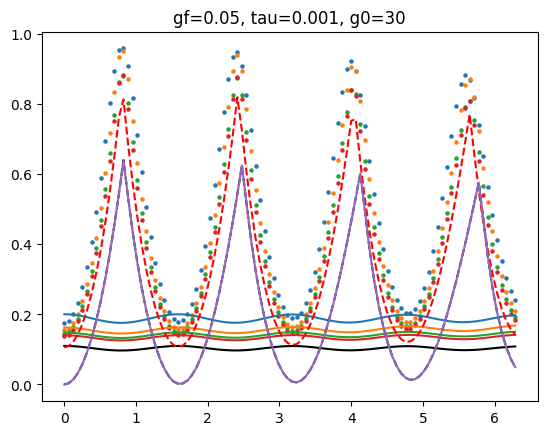

In [12]:
tau_index = 0
tau = taus_free[tau_index]
g0 = g0s[tau_index]
gf = gfs[-2]

psi = groundstate(g0, L)
psi_f = groundstate(0,L)

states_j = free_states[(tau, gf)]
t = free_times[(tau, gf)]
overlap = -log(nq.overlap(states_j, states_j[0]))/L
overlap2 = (nq.overlap(states_j, psi_f))
overlap3 = (nq.overlap(states_j, psi))


for i, n in enumerate(ns):
    y = dat[(tau, gf)][i]
    z = dat2[(tau,gf)][i]
    plot(t, -log(2*y)/(n-1), label=f"n={n}")
    scatter(t, -log(z)/(n), label=f"n={n}",s=5)

y = dat[(tau, gf)][0]
plot(t, overlap, "--k", label="overlap with tau state")
plot(t, -log(overlap2)/L, "k", label="overlap with gf state")
plot(t, -log(overlap3)/L, "--r", label="overlap with g0 state")

title(f"gf={gf}, tau={tau}, g0={g0}")
plot(t, -np.log(abs(nq.overlap(states_j, states_j[0])))/L)
#legend()
show()

In [19]:
import numpy as np
from scipy.integrate import solve_ivp

# -------- Adjustable parameters --------
k = pi/4            # momentum mode
g0 = 10.0           # initial g
gf = 0.0           # final g
tau = 1000        # quench duration
t0 = 0.0           # start time
tf = tau           # end time
# ---------------------------------------

# TFIM single-mode Hamiltonian (BdG form)
def H_k(k, g):
    return np.array([
        [2*(g - np.cos(k)), 2*np.sin(k)],
        [2*np.sin(k), -2*(g - np.cos(k))]
    ], dtype=complex)

# linear quench
def g_t(t):
    return g0 + (gf - g0)*(t - t0)/(tf - t0)

# equation for time evolution operator
def dUdt(t, U_flat):
    U = U_flat.reshape(2,2)
    H = H_k(k, g_t(t))
    dU = -1j * H @ U
    return dU.flatten()

# initial condition
U0 = np.eye(2, dtype=complex).flatten()

# integrate
sol = solve_ivp(dUdt, (t0, tf), U0, rtol=1e-10, atol=1e-10)

# final time evolution operator
U_final = sol.y[:, -1].reshape(2,2)

print("Final time evolution operator U(tf):")
print(U_final)

Final time evolution operator U(tf):
[[-0.14385262+0.32600456j  0.31112091+0.88103928j]
 [-0.31112091+0.88103928j -0.14385262-0.32600456j]]
